# 📊 Performance Analysis & Interpretation

Evaluate algorithm performance using SNR and ROC metrics.

## 🔹 1. Setup: Generate a Known Signal + Add Noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Signal: LFM chirp
fs = 10000
duration = 0.01
f0, f1 = 2000, 4000
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
k = (f1 - f0) / duration
template = np.cos(2 * np.pi * (f0 * t + 0.5 * k * t**2))

# Add noise
def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise

rx_signal = add_noise(template, snr_db=3)
rx_noise = add_noise(np.zeros_like(template), snr_db=3)

## 🔹 2. Compute SNR Before and After Matched Filter

In [2]:
def compute_snr(signal, noise_floor=1e-12):
    power_signal = np.mean(np.abs(signal)**2)
    return 10 * np.log10(power_signal / noise_floor)

# Before filter
snr_before = compute_snr(rx_signal)

# Matched filter
def matched_filter(rx, ref):
    return correlate(rx, ref, mode='same')

filtered = matched_filter(rx_signal, template)
snr_after = compute_snr(filtered)

print(f"SNR Before: {snr_before:.2f} dB")
print(f"SNR After: {snr_after:.2f} dB")

SNR Before: 118.45 dB
SNR After: 138.00 dB


## 🔹 3. Plot Filter Output vs Noise

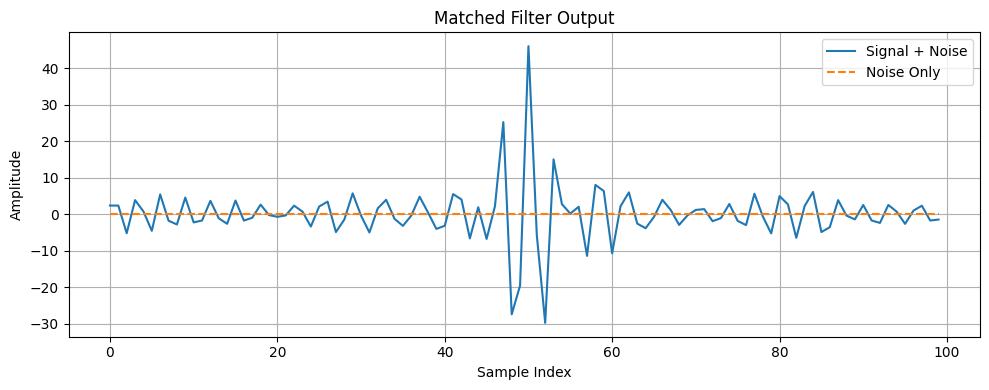

In [3]:
filtered_noise = matched_filter(rx_noise, template)

plt.figure(figsize=(10, 4))
plt.plot(filtered, label='Signal + Noise')
plt.plot(filtered_noise, label='Noise Only', linestyle='--')
plt.title("Matched Filter Output")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 4. ROC Curve (Detection Performance)

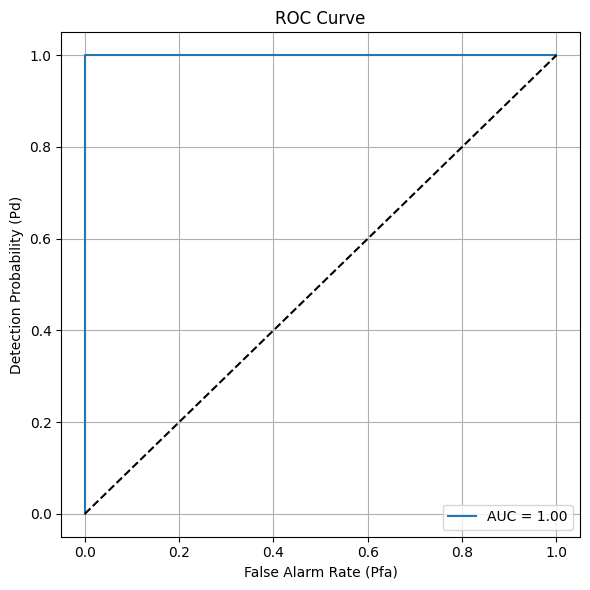

In [4]:
from sklearn.metrics import roc_curve, auc

def run_trials(template, snr_db, n_trials=500):
    scores_signal = []
    scores_noise = []
    for _ in range(n_trials):
        rx_s = add_noise(template, snr_db)
        rx_n = add_noise(np.zeros_like(template), snr_db)
        scores_signal.append(np.max(matched_filter(rx_s, template)))
        scores_noise.append(np.max(matched_filter(rx_n, template)))
    return np.array(scores_signal), np.array(scores_noise)

signal_scores, noise_scores = run_trials(template, snr_db=3)

y_true = np.concatenate([np.ones_like(signal_scores), np.zeros_like(noise_scores)])
y_scores = np.concatenate([signal_scores, noise_scores])

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Alarm Rate (Pfa)")
plt.ylabel("Detection Probability (Pd)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## ✅ Summary
- SNR gain shows effectiveness of matched filter
- ROC curve helps visualize detection performance
- Use these tools to compare algorithms, filters, or beamformers